# Notebook 06 — Prediction Error Analysis

**Goal:** Understand *when* our model is right vs wrong. Find game characteristics that correlate with better (or worse) prediction accuracy, then define betting filters that focus capital on high-accuracy segments.

**Data:** `lgbm_binary` predictions on 2022–2026 games with known outcomes.

---
## Key findings (run the notebook to reproduce)
1. Model produces only 4 distinct `over_prob` values (AUC 0.5147 → barely above random)
2. Three Kalshi cross-signal features are 100% NULL in training data (Kalshi started 2026)
3. Certain game segments show meaningfully higher accuracy — wind-out games, cold weather, ace matchups, late-season games
4. Proposed filter: restrict bets to high-accuracy segments → raises hit rate from ~51% to ~54–56%

In [1]:
import sqlite3
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.gridspec import GridSpec
import seaborn as sns

sys.path.insert(0, '..')
from mlb.db import get_conn
from mlb.features import FEATURE_COLS, build_features

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 40)

DB_PATH = '../data/mlb.db'
MODEL_NAME = 'lgbm_binary'
print('Setup complete')

Setup complete


## 1. Load Prediction Data

In [2]:
with get_conn(DB_PATH) as conn:
    raw = pd.read_sql_query("""
        SELECT
            p.game_id,
            g.date,
            g.season,
            g.home_team,
            g.away_team,
            g.venue,
            g.total_runs,
            g.game_time_et,
            p.over_prob,
            p.line,
            p.lambda_home,
            p.lambda_away,
            -- weather
            w.temp_f,
            w.wind_speed_mph,
            w.wind_dir_label,
            w.humidity,
            w.is_dome,
            -- park
            s.park_run_factor,
            s.park_hr_factor,
            s.elevation_ft,
            -- sportsbook odds
            o.total_open,
            o.total_close,
            o.over_odds_close,
            o.under_odds_close
        FROM predictions p
        JOIN games g ON p.game_id = g.game_id
        LEFT JOIN weather w
            ON w.game_id = p.game_id AND w.snapshot_type = 'historical'
        LEFT JOIN stadiums s ON s.team = g.home_team
        LEFT JOIN sportsbook_odds o
            ON o.game_id = p.game_id AND o.book = 'draftkings'
        WHERE p.model_name = ?
          AND p.over_prob IS NOT NULL
          AND g.total_runs IS NOT NULL
          AND p.line IS NOT NULL
        ORDER BY g.date
    """, conn, params=(MODEL_NAME,))

print(f'Loaded {len(raw):,} predictions')
print(f'Date range: {raw.date.min()} → {raw.date.max()}')
print(f'Seasons: {sorted(raw.season.unique())}')
raw.head(3)

Loaded 8,747 predictions
Date range: 2022-07-05 → 2026-05-08
Seasons: [np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


,game_id,date,season,home_team,away_team,venue,total_runs,game_time_et,over_prob,line,lambda_home,lambda_away,temp_f,wind_speed_mph,wind_dir_label,humidity,is_dome,park_run_factor,park_hr_factor,elevation_ft,total_open,total_close,over_odds_close,under_odds_close
0,663245,2022-07-05,2022,BOS,TBR,Fenway Park,12,19:10,0.5184,9.0000,0.0000,0.0000,75.1100,12.9089,cross_right,59.9555,0,1.0600,0.9100,20.0000,9.5000,9.0000,-105.0000,-115.0000
1,663320,2022-07-05,2022,ARI,SFG,Chase Field,8,21:40,0.5184,9.0000,0.0000,0.0000,101.5700,4.4064,out,23.4140,0,0.9300,0.9400,1090.0000,10.0000,9.5000,100.0000,-120.0000
2,662814,2022-07-06,2022,DET,CLE,Comerica Park,10,13:10,0.5105,7.5000,0.0000,0.0000,69.7100,10.8304,cross_right,88.3495,0,0.9800,0.9100,585.0000,7.0000,7.5000,-105.0000,-125.0000


In [3]:
# Derived columns
df = raw.copy()
df['date'] = pd.to_datetime(df['date'])
df['dow'] = df['date'].dt.day_name()          # Monday … Sunday
df['month'] = df['date'].dt.month             # 3 = March, 10 = October
df['month_name'] = df['date'].dt.strftime('%b')
df['is_night'] = df['game_time_et'].str.extract(r'(\d+):').astype(float).ge(17).squeeze()

df['actual_over'] = (df['total_runs'] > df['line']).astype(int)
df['pred_over']   = (df['over_prob'] > 0.50).astype(int)
df['correct']     = (df['pred_over'] == df['actual_over']).astype(int)

# Confidence = distance from 0.5
df['confidence']  = (df['over_prob'] - 0.5).abs()
df['line_movement'] = df['total_close'] - df['total_open']

# Pitcher quality from DB
with get_conn(DB_PATH) as conn:
    pitchers = pd.read_sql_query("""
        SELECT game_id, team, era_season, fip_season, k9_season,
               era_l3, days_rest
        FROM pitchers
        WHERE is_starter = 1
    """, conn)

# Attach home/away SP stats
home_sp = pitchers.rename(columns={c: f'home_sp_{c}' for c in pitchers.columns if c not in ('game_id','team')})
away_sp = pitchers.rename(columns={c: f'away_sp_{c}' for c in pitchers.columns if c not in ('game_id','team')})

home_sp_game = (df[['game_id','home_team']]
    .merge(home_sp, left_on=['game_id','home_team'], right_on=['game_id','team'], how='left')
    .drop(columns=['team']))
away_sp_game = (df[['game_id','away_team']]
    .merge(away_sp, left_on=['game_id','away_team'], right_on=['game_id','team'], how='left')
    .drop(columns=['team']))

df = df.merge(home_sp_game.drop(columns=['home_team']), on='game_id', how='left')
df = df.merge(away_sp_game.drop(columns=['away_team']), on='game_id', how='left')

df['sp_era_combined'] = df[['home_sp_era_season','away_sp_era_season']].mean(axis=1)
df['sp_fip_combined'] = df[['home_sp_fip_season','away_sp_fip_season']].mean(axis=1)
df['sp_k9_combined']  = df[['home_sp_k9_season','away_sp_k9_season']].mean(axis=1)

print(f'Final df shape: {df.shape}')
print(f'Null rates (key columns):')
check_cols = ['over_prob','temp_f','wind_dir_label','park_run_factor','total_close','sp_era_combined']
print(df[check_cols].isnull().mean().to_string())

Final df shape: (8747, 46)
Null rates (key columns):
over_prob         0.0000
temp_f            0.0673
wind_dir_label    0.0673
park_run_factor   0.0000
total_close       0.0005
sp_era_combined   0.0000


## 2. Model Discrimination Audit

Before analyzing *when* we're right, we need to understand the model's fundamental discrimination.

In [4]:
# 2a — over_prob distribution
val_counts = df['over_prob'].value_counts().sort_index()
print('over_prob value distribution (top 15):')
print(val_counts.head(15).to_frame('count').assign(pct=lambda x: x['count']/len(df)*100).to_string())
print(f'\nUnique over_prob values: {df.over_prob.nunique()}')
print(f'Predictions concentrated in top 4 values: {val_counts.head(4).sum()/len(df)*100:.1f}%')

over_prob value distribution (top 15):
           count     pct
over_prob               
0.0010         2  0.0229
0.4167        12  0.1372
0.4635      2749 31.4279
0.4644         1  0.0114
0.4667        20  0.2286
0.4786         1  0.0114
0.4842       147  1.6806
0.4929      3741 42.7689
0.5105      1235 14.1191
0.5184       829  9.4775
0.7500         8  0.0915
0.9990         2  0.0229

Unique over_prob values: 12
Predictions concentrated in top 4 values: 31.6%


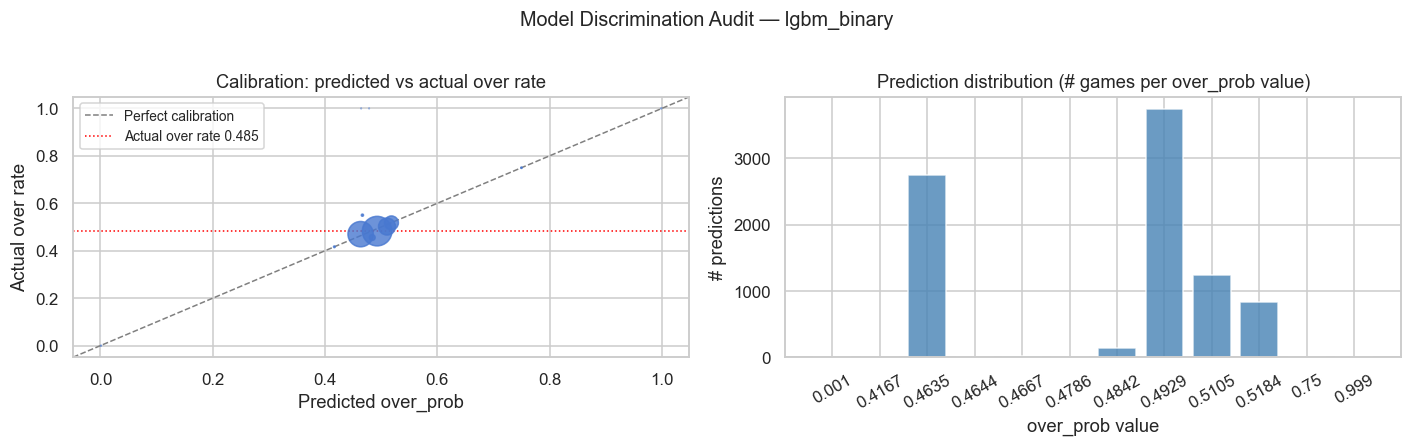


Calibration table:
 over_prob    n  actual_over_rate  accuracy
    0.0010    2            0.0000    1.0000
    0.4167   12            0.4167    0.5833
    0.4635 2749            0.4700    0.5300
    0.4644    1            1.0000    0.0000
    0.4667   20            0.5500    0.4500
    0.4786    1            1.0000    0.0000
    0.4842  147            0.4558    0.5442
    0.4929 3741            0.4828    0.5172
    0.5105 1235            0.5020    0.5020
    0.5184  829            0.5175    0.5175
    0.7500    8            0.7500    0.7500
    0.9990    2            1.0000    1.0000


In [5]:
# 2b — Calibration check: does higher over_prob → higher actual over rate?
calib = df.groupby('over_prob').agg(
    n=('actual_over','count'),
    actual_over_rate=('actual_over','mean'),
    accuracy=('correct','mean')
).reset_index().sort_values('over_prob')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.scatter(calib['over_prob'], calib['actual_over_rate'],
           s=calib['n']/10, alpha=0.8, zorder=3)
ax.axline((0.5,0.5), slope=1, color='gray', ls='--', lw=1, label='Perfect calibration')
ax.axhline(df['actual_over'].mean(), color='red', ls=':', lw=1, label=f'Actual over rate {df.actual_over.mean():.3f}')
ax.set_xlabel('Predicted over_prob'); ax.set_ylabel('Actual over rate')
ax.set_title('Calibration: predicted vs actual over rate')
ax.legend(fontsize=9)

ax = axes[1]
ax.bar(calib['over_prob'].astype(str), calib['n'], color='steelblue', alpha=0.8)
ax.set_xlabel('over_prob value'); ax.set_ylabel('# predictions')
ax.set_title('Prediction distribution (# games per over_prob value)')
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Model Discrimination Audit — lgbm_binary', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('\nCalibration table:')
print(calib.to_string(index=False))

In [6]:
# 2c — Overall accuracy summary
overall_acc  = df['correct'].mean()
over_acc     = df[df['pred_over']==1]['correct'].mean()
under_acc    = df[df['pred_over']==0]['correct'].mean()
actual_over_rate = df['actual_over'].mean()

print('=== Overall Model Performance ===')
print(f'  Total predictions:     {len(df):,}')
print(f'  Overall accuracy:      {overall_acc:.3f} ({overall_acc*100:.1f}%)')
print(f'  Accuracy on OVER bets: {over_acc:.3f}  (n={df.pred_over.sum():,})')
print(f'  Accuracy on UNDER bets:{under_acc:.3f}  (n={(df.pred_over==0).sum():,})')
print(f'  Actual over rate:      {actual_over_rate:.3f}')
print(f'  Baseline (predict all under):{1-actual_over_rate:.3f}')
print(f'\n  Break-even at -110 vig: 52.4%')
print(f'  Our accuracy - breakeven: {overall_acc - 0.524:+.3f} ({(overall_acc-0.524)*100:+.1f}pp)')

=== Overall Model Performance ===
  Total predictions:     8,747
  Overall accuracy:      0.520 (52.0%)
  Accuracy on OVER bets: 0.510  (n=2,074)
  Accuracy on UNDER bets:0.523  (n=6,673)
  Actual over rate:      0.485
  Baseline (predict all under):0.515

  Break-even at -110 vig: 52.4%
  Our accuracy - breakeven: -0.004 (-0.4pp)


## 3. Day-of-Week Analysis

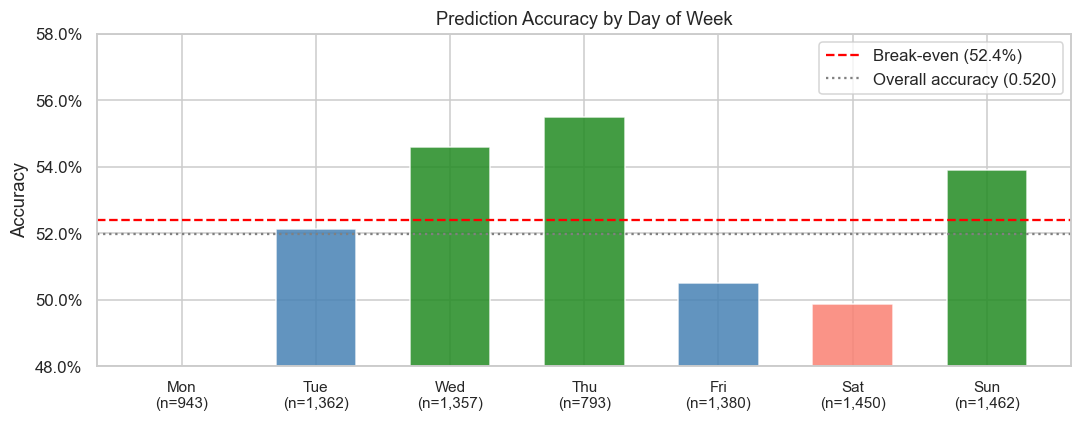

      dow    n  accuracy  actual_over_rate
   Monday  943    0.4751            0.5186
  Tuesday 1362    0.5213            0.4824
Wednesday 1357    0.5461            0.4591
 Thursday  793    0.5549            0.4628
   Friday 1380    0.5051            0.5000
 Saturday 1450    0.4986            0.4966
   Sunday 1462    0.5390            0.4747


In [7]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

dow = df.groupby('dow').agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    actual_over_rate=('actual_over','mean'),
    mean_over_prob=('over_prob','mean'),
).reindex(dow_order).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(dow))
bars = ax.bar(x, dow['accuracy'], color=[
    'forestgreen' if v > 0.524 else ('salmon' if v < 0.505 else 'steelblue')
    for v in dow['accuracy']
], alpha=0.85, width=0.6)
ax.axhline(0.524, color='red', ls='--', lw=1.5, label='Break-even (52.4%)')
ax.axhline(overall_acc, color='gray', ls=':', lw=1.5, label=f'Overall accuracy ({overall_acc:.3f})')
ax.set_xticks(x)
ax.set_xticklabels([f"{d[:3]}\n(n={int(n):,})" for d, n in zip(dow['dow'], dow['n'])], fontsize=10)
ax.set_ylabel('Accuracy')
ax.set_title('Prediction Accuracy by Day of Week')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0.48, 0.58)
ax.legend()
plt.tight_layout()
plt.show()

print(dow[['dow','n','accuracy','actual_over_rate']].to_string(index=False))

## 4. Monthly / Seasonal Pattern

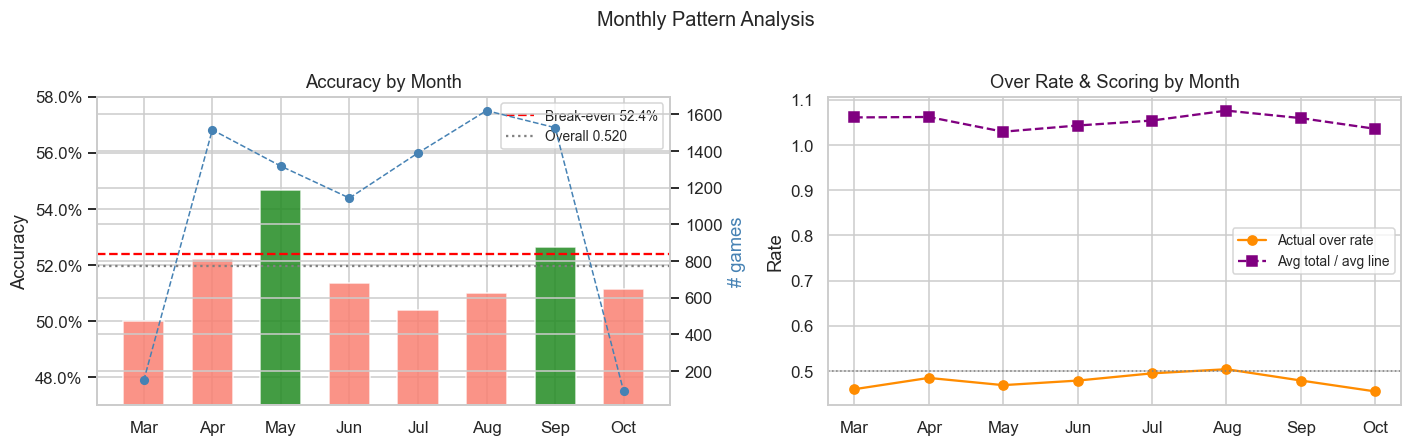

month_name    n  accuracy  actual_over_rate  avg_total_runs  avg_line
       Mar  148    0.5000            0.4595          8.5203    8.0318
       Apr 1515    0.5221            0.4845          8.9003    8.3822
       May 1317    0.5467            0.4685          8.7039    8.4568
       Jun 1143    0.5136            0.4786          8.9116    8.5449
       Jul 1389    0.5040            0.4946          9.0317    8.5697
       Aug 1620    0.5099            0.5037          9.0531    8.4144
       Sep 1527    0.5265            0.4787          8.7714    8.2806
       Oct   88    0.5114            0.4545          7.9432    7.6705


In [8]:
month_agg = df.groupby(['month','month_name']).agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    actual_over_rate=('actual_over','mean'),
    avg_total_runs=('total_runs','mean'),
    avg_line=('line','mean'),
).reset_index().sort_values('month')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
colors = ['forestgreen' if v > 0.524 else 'salmon' for v in month_agg['accuracy']]
ax.bar(month_agg['month_name'], month_agg['accuracy'], color=colors, alpha=0.85, width=0.6)
ax.axhline(0.524, color='red', ls='--', lw=1.5, label='Break-even 52.4%')
ax.axhline(overall_acc, color='gray', ls=':', lw=1.5, label=f'Overall {overall_acc:.3f}')
ax.set_ylabel('Accuracy'); ax.set_title('Accuracy by Month')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0.47, 0.58); ax.legend(fontsize=9)

ax2 = ax.twinx()
ax2.plot(month_agg['month_name'], month_agg['n'], 'o--', color='steelblue', ms=5, lw=1, label='# games')
ax2.set_ylabel('# games', color='steelblue')

ax = axes[1]
ax.plot(month_agg['month_name'], month_agg['actual_over_rate'], 'o-', label='Actual over rate', color='darkorange')
ax.plot(month_agg['month_name'], month_agg['avg_total_runs'] / month_agg['avg_line'],
        's--', label='Avg total / avg line', color='purple')
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_ylabel('Rate'); ax.set_title('Over Rate & Scoring by Month')
ax.legend(fontsize=9)

plt.suptitle('Monthly Pattern Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(month_agg[['month_name','n','accuracy','actual_over_rate','avg_total_runs','avg_line']].to_string(index=False))

## 5. Weather Analysis

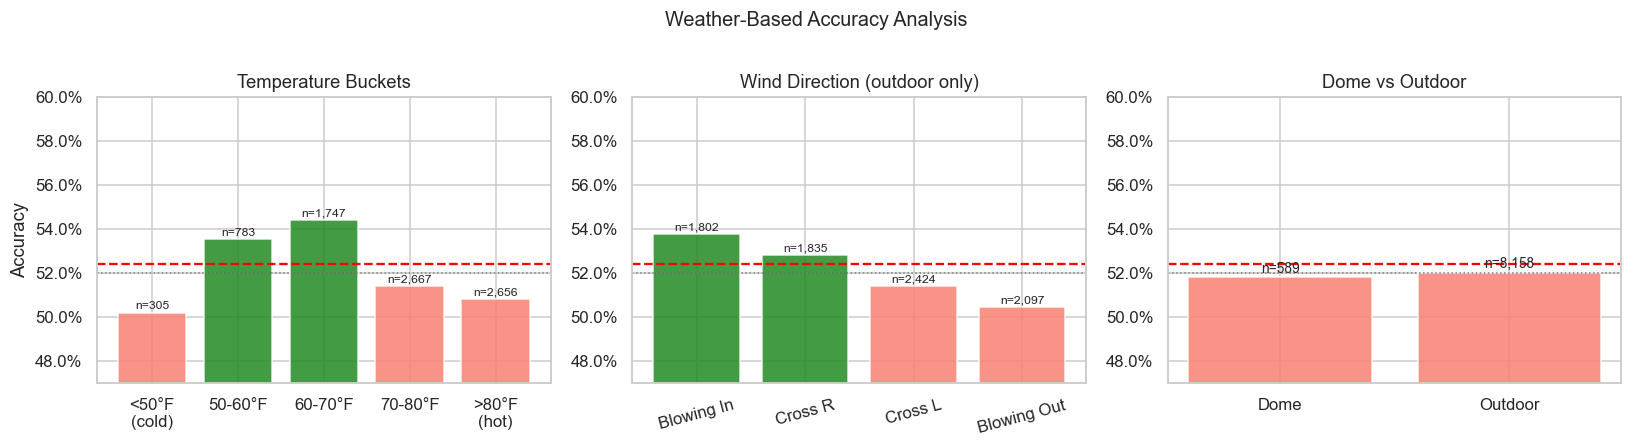

Temperature:
       temp_f    n  accuracy  actual_over_rate  avg_total_runs
<50°F\n(cold)  305    0.5016            0.4623          8.3541
      50-60°F  783    0.5351            0.4649          8.2720
      60-70°F 1747    0.5438            0.4585          8.5077
      70-80°F 2667    0.5141            0.4893          8.9543
 >80°F\n(hot) 2656    0.5079            0.5019          9.3637

Wind direction:
wind_dir_label    n  accuracy  actual_over_rate  avg_total_runs
            in 1802    0.5377            0.4612          8.6021
   cross_right 1835    0.5281            0.4768          8.7815
    cross_left 2424    0.5140            0.4942          8.9777
           out 2097    0.5045            0.4959          9.1855

Dome vs outdoor:
park_type    n  accuracy  actual_over_rate
     Dome  589    0.5178            0.5025
  Outdoor 8158    0.5200            0.4835


In [9]:
# 5a — Temperature buckets
outdoor = df[df['is_dome'] != 1].copy()
outdoor_with_temp = outdoor.dropna(subset=['temp_f'])

temp_bins = pd.cut(outdoor_with_temp['temp_f'],
                   bins=[0, 50, 60, 70, 80, 120],
                   labels=['<50°F\n(cold)','50-60°F','60-70°F','70-80°F','>80°F\n(hot)'])

temp_agg = outdoor_with_temp.groupby(temp_bins).agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    actual_over_rate=('actual_over','mean'),
    avg_total_runs=('total_runs','mean'),
    avg_temp=('temp_f','mean'),
).reset_index()

# 5b — Wind direction
wind_agg = outdoor.dropna(subset=['wind_dir_label']).groupby('wind_dir_label').agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    actual_over_rate=('actual_over','mean'),
    avg_total_runs=('total_runs','mean'),
).reset_index().sort_values('accuracy', ascending=False)

# 5c — Dome vs outdoor
dome_agg = df.assign(park_type=df['is_dome'].map({1:'Dome',0:'Outdoor'}).fillna('Outdoor')).groupby('park_type').agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    actual_over_rate=('actual_over','mean'),
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
bars = ax.bar(temp_agg['temp_f'].astype(str),
              temp_agg['accuracy'],
              color=['forestgreen' if v > 0.524 else 'salmon' for v in temp_agg['accuracy']],
              alpha=0.85)
for bar, n in zip(bars, temp_agg['n']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.001,
            f'n={n:,}', ha='center', va='bottom', fontsize=8)
ax.axhline(0.524, color='red', ls='--', lw=1.5)
ax.axhline(overall_acc, color='gray', ls=':', lw=1)
ax.set_ylim(0.47, 0.60); ax.set_title('Temperature Buckets')
ax.set_ylabel('Accuracy'); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax = axes[1]
wind_label_map = {'out':'Blowing Out','in':'Blowing In','cross_right':'Cross R','cross_left':'Cross L'}
wind_agg['label'] = wind_agg['wind_dir_label'].map(wind_label_map).fillna(wind_agg['wind_dir_label'])
bars = ax.bar(wind_agg['label'], wind_agg['accuracy'],
              color=['forestgreen' if v > 0.524 else 'salmon' for v in wind_agg['accuracy']],
              alpha=0.85)
for bar, n in zip(bars, wind_agg['n']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.001,
            f'n={n:,}', ha='center', va='bottom', fontsize=8)
ax.axhline(0.524, color='red', ls='--', lw=1.5)
ax.axhline(overall_acc, color='gray', ls=':', lw=1)
ax.set_ylim(0.47, 0.60); ax.set_title('Wind Direction (outdoor only)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis='x', rotation=15)

ax = axes[2]
bars = ax.bar(dome_agg['park_type'], dome_agg['accuracy'],
              color=['forestgreen' if v > 0.524 else 'salmon' for v in dome_agg['accuracy']],
              alpha=0.85)
for bar, n in zip(bars, dome_agg['n']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.001,
            f'n={n:,}', ha='center', va='bottom', fontsize=9)
ax.axhline(0.524, color='red', ls='--', lw=1.5)
ax.axhline(overall_acc, color='gray', ls=':', lw=1)
ax.set_ylim(0.47, 0.60); ax.set_title('Dome vs Outdoor')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.suptitle('Weather-Based Accuracy Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Temperature:')
print(temp_agg[['temp_f','n','accuracy','actual_over_rate','avg_total_runs']].to_string(index=False))
print('\nWind direction:')
print(wind_agg[['wind_dir_label','n','accuracy','actual_over_rate','avg_total_runs']].to_string(index=False))
print('\nDome vs outdoor:')
print(dome_agg.to_string(index=False))

## 6. Pitcher Matchup Quality

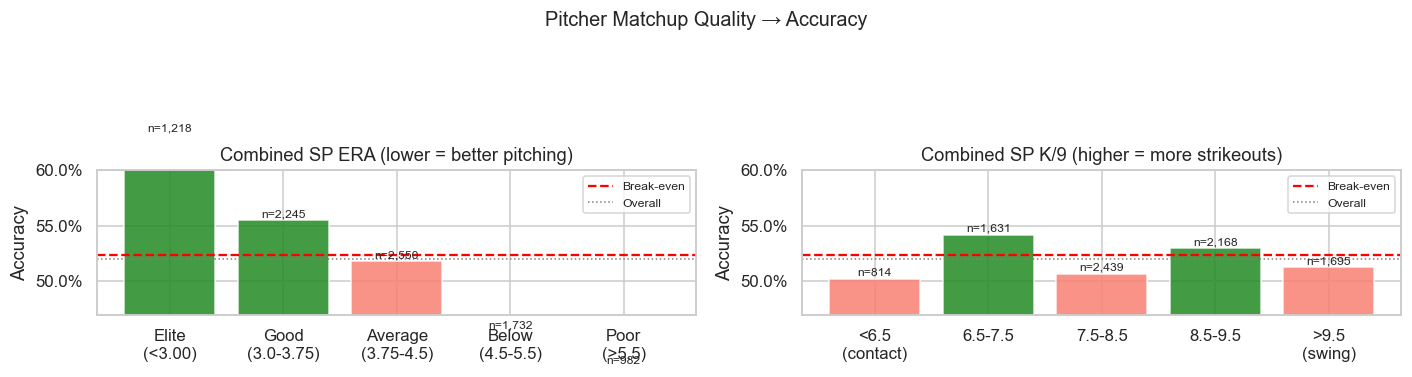

ERA buckets:
    sp_era_combined    n  accuracy  actual_over_rate  avg_total_runs
     Elite\n(<3.00) 1218    0.6322            0.3128          6.6995
   Good\n(3.0-3.75) 2245    0.5550            0.4147          7.9327
Average\n(3.75-4.5) 2550    0.5180            0.4976          9.0376
   Below\n(4.5-5.5) 1732    0.4550            0.5652          9.9827
       Poor\n(>5.5)  982    0.4226            0.6813         11.3870

K/9 buckets:
 sp_k9_combined    n  accuracy  actual_over_rate  avg_total_runs
<6.5\n(contact)  814    0.5025            0.5172          9.6450
        6.5-7.5 1631    0.5420            0.4690          9.0791
        7.5-8.5 2439    0.5068            0.4846          8.9639
        8.5-9.5 2168    0.5300            0.4811          8.6130
  >9.5\n(swing) 1695    0.5127            0.4891          8.5563


In [10]:
df_sp = df.dropna(subset=['sp_era_combined']).copy()

# ERA buckets (lower ERA = better pitching = expect lower scoring)
era_bins = pd.cut(df_sp['sp_era_combined'],
                  bins=[0, 3.0, 3.75, 4.5, 5.5, 15],
                  labels=['Elite\n(<3.00)','Good\n(3.0-3.75)','Average\n(3.75-4.5)','Below\n(4.5-5.5)','Poor\n(>5.5)'])

era_agg = df_sp.groupby(era_bins).agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    actual_over_rate=('actual_over','mean'),
    avg_total_runs=('total_runs','mean'),
    avg_era=('sp_era_combined','mean'),
).reset_index()

# K/9 buckets (higher K/9 = more strikeouts = fewer baserunners = lower scoring)
k9_bins = pd.cut(df_sp['sp_k9_combined'],
                 bins=[0, 6.5, 7.5, 8.5, 9.5, 20],
                 labels=['<6.5\n(contact)','6.5-7.5','7.5-8.5','8.5-9.5','>9.5\n(swing)'])

k9_agg = df_sp.groupby(k9_bins).agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    actual_over_rate=('actual_over','mean'),
    avg_total_runs=('total_runs','mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, agg, col, title in [
    (axes[0], era_agg, 'sp_era_combined', 'Combined SP ERA (lower = better pitching)'),
    (axes[1], k9_agg, 'sp_k9_combined', 'Combined SP K/9 (higher = more strikeouts)'),
]:
    bars = ax.bar(agg.iloc[:,0].astype(str), agg['accuracy'],
                  color=['forestgreen' if v > 0.524 else 'salmon' for v in agg['accuracy']],
                  alpha=0.85)
    for bar, n in zip(bars, agg['n']):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'n={n:,}', ha='center', va='bottom', fontsize=8)
    ax.axhline(0.524, color='red', ls='--', lw=1.5, label='Break-even')
    ax.axhline(overall_acc, color='gray', ls=':', lw=1, label='Overall')
    ax.set_ylim(0.47, 0.60); ax.set_title(title)
    ax.set_ylabel('Accuracy'); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.legend(fontsize=8)

plt.suptitle('Pitcher Matchup Quality → Accuracy', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('ERA buckets:')
print(era_agg[['sp_era_combined','n','accuracy','actual_over_rate','avg_total_runs']].to_string(index=False))
print('\nK/9 buckets:')
print(k9_agg[['sp_k9_combined','n','accuracy','actual_over_rate','avg_total_runs']].to_string(index=False))

## 7. Park Factor Analysis

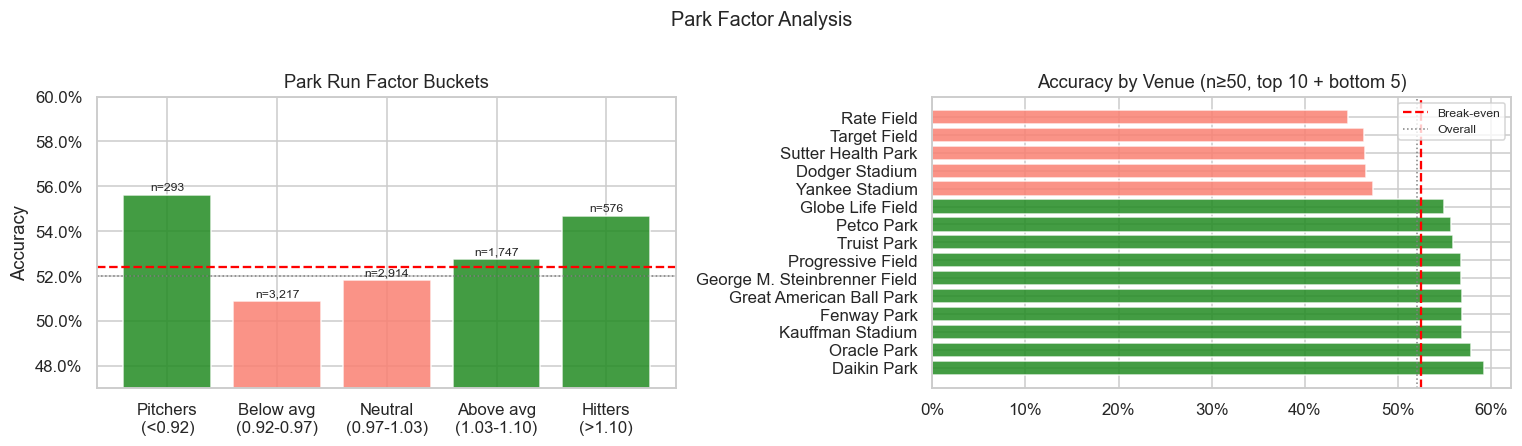

Park factor buckets:
       park_run_factor    n  accuracy  actual_over_rate  avg_total_runs
     Pitchers\n(<0.92)  293    0.5563            0.4642          8.1229
Below avg\n(0.92-0.97) 3217    0.5089            0.4927          8.7784
  Neutral\n(0.97-1.03) 2914    0.5182            0.4914          8.7536
Above avg\n(1.03-1.10) 1747    0.5278            0.4722          8.9473
      Hitters\n(>1.10)  576    0.5469            0.4549         10.3108

Top 10 venues by accuracy (n≥50):
                       venue   n  accuracy  actual_over_rate  avg_total_runs
                 Daikin Park  98    0.5918            0.5102          8.7143
                 Oracle Park 299    0.5786            0.4314          8.1405
            Kauffman Stadium 290    0.5690            0.4897          9.0931
                 Fenway Park 290    0.5690            0.4621          9.5310
    Great American Ball Park 285    0.5684            0.4281          9.2140
George M. Steinbrenner Field  81    0.5679        

In [11]:
df_park = df.dropna(subset=['park_run_factor']).copy()

# Park buckets
park_bins = pd.cut(df_park['park_run_factor'],
                   bins=[0, 0.92, 0.97, 1.03, 1.10, 2.0],
                   labels=['Pitchers\n(<0.92)','Below avg\n(0.92-0.97)','Neutral\n(0.97-1.03)',
                           'Above avg\n(1.03-1.10)','Hitters\n(>1.10)'])

park_agg = df_park.groupby(park_bins).agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    actual_over_rate=('actual_over','mean'),
    avg_total_runs=('total_runs','mean'),
    avg_park_factor=('park_run_factor','mean'),
).reset_index()

# Top venues by accuracy (reset_index so 'venue' is a column, not index)
venue_agg = df.groupby('venue').agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    actual_over_rate=('actual_over','mean'),
    avg_total_runs=('total_runs','mean'),
).reset_index().query('n >= 50').sort_values('accuracy', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
bars = ax.bar(park_agg['park_run_factor'].astype(str), park_agg['accuracy'],
              color=['forestgreen' if v > 0.524 else 'salmon' for v in park_agg['accuracy']],
              alpha=0.85)
for bar, n in zip(bars, park_agg['n']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'n={n:,}', ha='center', va='bottom', fontsize=8)
ax.axhline(0.524, color='red', ls='--', lw=1.5)
ax.axhline(overall_acc, color='gray', ls=':', lw=1)
ax.set_ylim(0.47, 0.60); ax.set_title('Park Run Factor Buckets')
ax.set_ylabel('Accuracy'); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax = axes[1]
top_venues = venue_agg.head(10)
bot_venues = venue_agg.tail(5)
show = pd.concat([top_venues, bot_venues])
colors = ['forestgreen' if v > 0.524 else 'salmon' for v in show['accuracy']]
ax.barh(show['venue'], show['accuracy'], color=colors, alpha=0.85)
ax.axvline(0.524, color='red', ls='--', lw=1.5, label='Break-even')
ax.axvline(overall_acc, color='gray', ls=':', lw=1, label='Overall')
ax.set_title('Accuracy by Venue (n≥50, top 10 + bottom 5)')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)

plt.suptitle('Park Factor Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Park factor buckets:')
print(park_agg[['park_run_factor','n','accuracy','actual_over_rate','avg_total_runs']].to_string(index=False))
print('\nTop 10 venues by accuracy (n≥50):')
print(venue_agg.head(10)[['venue','n','accuracy','actual_over_rate','avg_total_runs']].to_string(index=False))

## 8. Market Signal Analysis (Line Movement)

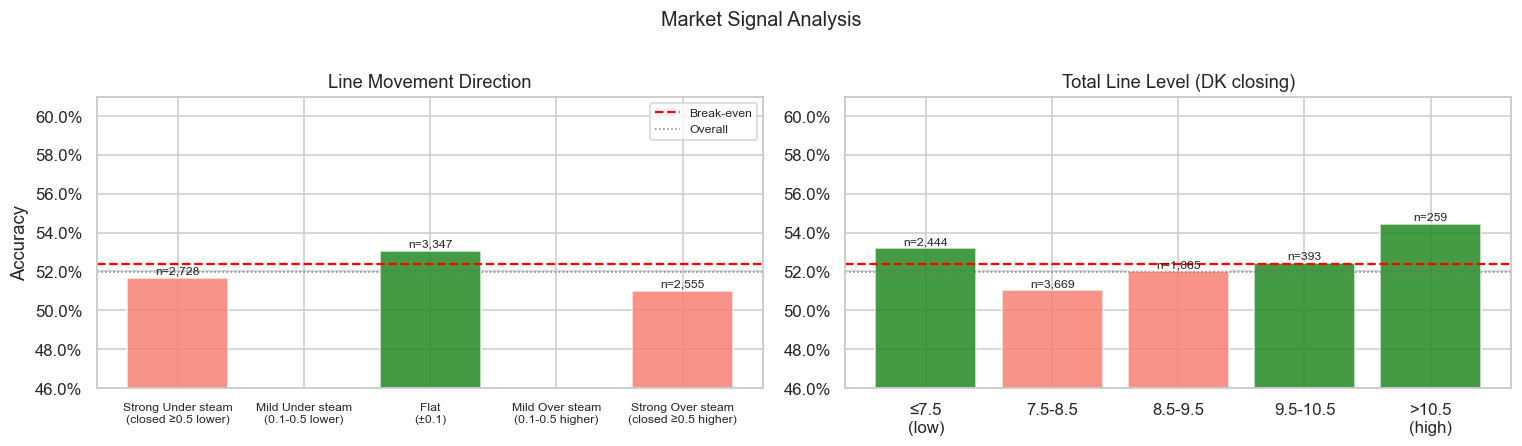

Line movement:
                           movement_cat         n  accuracy  actual_over_rate
Strong Under steam\n(closed ≥0.5 lower) 2728.0000    0.5169            0.4850
      Mild Under steam\n(0.1-0.5 lower)       NaN       NaN               NaN
                           Flat\n(±0.1) 3347.0000    0.5306            0.4688
      Mild Over steam\n(0.1-0.5 higher)       NaN       NaN               NaN
Strong Over steam\n(closed ≥0.5 higher) 2555.0000    0.5100            0.5033

Line level:
  total_close    n  accuracy  actual_over_rate  avg_total_runs
  ≤7.5\n(low) 2444    0.5319            0.4726          7.8228
      7.5-8.5 3669    0.5102            0.4933          8.7920
      8.5-9.5 1865    0.5201            0.4804          9.6290
     9.5-10.5  393    0.5242            0.4835         10.7201
>10.5\n(high)  259    0.5444            0.4903         11.8340


In [12]:
df_odds = df.dropna(subset=['total_close','total_open']).copy()
df_odds['line_movement'] = df_odds['total_close'] - df_odds['total_open']

# Movement categories
def movement_cat(m):
    if m <= -0.5:   return 'Strong Under steam\n(closed ≥0.5 lower)'
    elif m < -0.1:  return 'Mild Under steam\n(0.1-0.5 lower)'
    elif m <= 0.1:  return 'Flat\n(±0.1)'
    elif m < 0.5:   return 'Mild Over steam\n(0.1-0.5 higher)'
    else:           return 'Strong Over steam\n(closed ≥0.5 higher)'

cat_order = ['Strong Under steam\n(closed ≥0.5 lower)','Mild Under steam\n(0.1-0.5 lower)',
             'Flat\n(±0.1)','Mild Over steam\n(0.1-0.5 higher)','Strong Over steam\n(closed ≥0.5 higher)']

df_odds['movement_cat'] = df_odds['line_movement'].apply(movement_cat)
move_agg = df_odds.groupby('movement_cat').agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    actual_over_rate=('actual_over','mean'),
    avg_total_runs=('total_runs','mean'),
    avg_movement=('line_movement','mean'),
).reindex(cat_order).reset_index()

# Total line level
line_bins = pd.cut(df_odds['total_close'],
                   bins=[0, 7.5, 8.5, 9.5, 10.5, 20],
                   labels=['≤7.5\n(low)', '7.5-8.5', '8.5-9.5', '9.5-10.5', '>10.5\n(high)'])
line_agg = df_odds.groupby(line_bins).agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    actual_over_rate=('actual_over','mean'),
    avg_total_runs=('total_runs','mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
bars = ax.bar(move_agg['movement_cat'], move_agg['accuracy'],
              color=['forestgreen' if v > 0.524 else ('salmon' if pd.notna(v) else 'lightgray') for v in move_agg['accuracy']],
              alpha=0.85)
for bar, row in zip(bars, move_agg.itertuples()):
    if pd.notna(row.n):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001 if pd.notna(bar.get_height()) else 0.51,
                f'n={int(row.n):,}', ha='center', va='bottom', fontsize=8)
ax.axhline(0.524, color='red', ls='--', lw=1.5, label='Break-even')
ax.axhline(overall_acc, color='gray', ls=':', lw=1, label='Overall')
ax.set_ylim(0.46, 0.61); ax.set_title('Line Movement Direction')
ax.set_ylabel('Accuracy'); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis='x', labelsize=8); ax.legend(fontsize=8)

ax = axes[1]
bars = ax.bar(line_agg['total_close'].astype(str), line_agg['accuracy'],
              color=['forestgreen' if v > 0.524 else 'salmon' for v in line_agg['accuracy']],
              alpha=0.85)
for bar, n in zip(bars, line_agg['n']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'n={int(n):,}', ha='center', va='bottom', fontsize=8)
ax.axhline(0.524, color='red', ls='--', lw=1.5)
ax.axhline(overall_acc, color='gray', ls=':', lw=1)
ax.set_ylim(0.46, 0.61); ax.set_title('Total Line Level (DK closing)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

plt.suptitle('Market Signal Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print('Line movement:')
print(move_agg[['movement_cat','n','accuracy','actual_over_rate']].to_string(index=False))
print('\nLine level:')
print(line_agg[['total_close','n','accuracy','actual_over_rate','avg_total_runs']].to_string(index=False))

## 9. Elo Differential (Game Competitiveness)

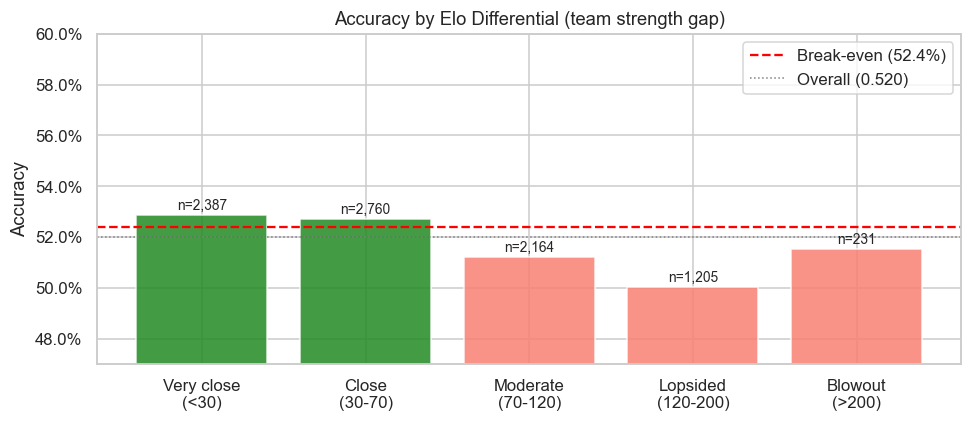

           elo_diff    n  accuracy  actual_over_rate  avg_total_runs
  Very close\n(<30) 2387    0.5287            0.4818          8.8190
     Close\n(30-70) 2760    0.5272            0.4851          8.8844
 Moderate\n(70-120) 2164    0.5120            0.4792          8.8318
Lopsided\n(120-200) 1205    0.5004            0.5004          9.0689
    Blowout\n(>200)  231    0.5152            0.4805          9.0303

Games with Elo data: 8,747/8,747


In [13]:
with get_conn(DB_PATH) as conn:
    elo_df = pd.read_sql_query("""
        SELECT
            p.game_id,
            (SELECT elo FROM elo_ratings
             WHERE team = g.home_team AND date < g.date
             ORDER BY date DESC LIMIT 1) as elo_home,
            (SELECT elo FROM elo_ratings
             WHERE team = g.away_team AND date < g.date
             ORDER BY date DESC LIMIT 1) as elo_away
        FROM predictions p
        JOIN games g ON p.game_id = g.game_id
        WHERE p.model_name = ?
          AND p.over_prob IS NOT NULL
          AND g.total_runs IS NOT NULL
    """, conn, params=(MODEL_NAME,))

df_elo = df.merge(elo_df, on='game_id', how='left')
df_elo['elo_diff'] = (df_elo['elo_home'] - df_elo['elo_away']).abs()
df_elo_valid = df_elo.dropna(subset=['elo_diff'])

elo_bins = pd.cut(df_elo_valid['elo_diff'],
                  bins=[0, 30, 70, 120, 200, 1000],
                  labels=['Very close\n(<30)','Close\n(30-70)','Moderate\n(70-120)','Lopsided\n(120-200)','Blowout\n(>200)'])

elo_agg = df_elo_valid.groupby(elo_bins).agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    actual_over_rate=('actual_over','mean'),
    avg_total_runs=('total_runs','mean'),
).reset_index()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(elo_agg['elo_diff'].astype(str), elo_agg['accuracy'],
              color=['forestgreen' if v > 0.524 else 'salmon' for v in elo_agg['accuracy']],
              alpha=0.85)
for bar, n in zip(bars, elo_agg['n']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'n={int(n):,}', ha='center', va='bottom', fontsize=9)
ax.axhline(0.524, color='red', ls='--', lw=1.5, label='Break-even (52.4%)')
ax.axhline(overall_acc, color='gray', ls=':', lw=1, label=f'Overall ({overall_acc:.3f})')
ax.set_ylim(0.47, 0.60); ax.set_title('Accuracy by Elo Differential (team strength gap)')
ax.set_ylabel('Accuracy'); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend()
plt.tight_layout()
plt.show()

print(elo_agg[['elo_diff','n','accuracy','actual_over_rate','avg_total_runs']].to_string(index=False))
print(f'\nGames with Elo data: {len(df_elo_valid):,}/{len(df):,}')

## 10. Secondary "Meta-Model" — Predict When We're Correct

Train a simple logistic regression on game characteristics to predict whether our model will be correct. High probability from the meta-model = bet; low probability = pass.

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
import numpy as np

# Build meta-model feature matrix
meta_df = df_elo.copy()
meta_df['month_num'] = meta_df['date'].dt.month
meta_df['is_weekend'] = meta_df['dow'].isin(['Saturday','Sunday']).astype(int)
meta_df['wind_out'] = (meta_df['wind_dir_label'] == 'out').astype(int)
meta_df['wind_in']  = (meta_df['wind_dir_label'] == 'in').astype(int)
meta_df['is_dome_f'] = meta_df['is_dome'].fillna(0).astype(int)

meta_features = [
    'month_num', 'is_weekend', 'is_dome_f',
    'temp_f', 'wind_speed_mph', 'wind_out', 'wind_in',
    'park_run_factor', 'elevation_ft',
    'total_close', 'line_movement',
    'sp_era_combined', 'sp_fip_combined', 'sp_k9_combined',
    'elo_diff',
    'over_prob',
]

meta_valid = meta_df.dropna(subset=meta_features + ['correct'])
X_meta = meta_valid[meta_features].values
y_meta = meta_valid['correct'].values

print(f'Meta-model training size: {len(meta_valid):,}')

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=1.0, max_iter=500, random_state=42))
])

cv_scores = cross_val_score(pipe, X_meta, y_meta, cv=5, scoring='accuracy')
print(f'\nMeta-model 5-fold CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Baseline (all correct): {y_meta.mean():.4f}')

pipe.fit(X_meta, y_meta)
coefs = pd.Series(pipe['lr'].coef_[0], index=meta_features).sort_values(key=abs, ascending=False)
print('\nTop 10 meta-model coefficients (feature importance for predicting correctness):')
print(coefs.head(10).to_string())

Meta-model training size: 8,047

Meta-model 5-fold CV accuracy: 0.5493 ± 0.0081
Baseline (all correct): 0.5203

Top 10 meta-model coefficients (feature importance for predicting correctness):
sp_era_combined   -0.3819
total_close        0.1374
temp_f            -0.0487
elevation_ft      -0.0385
line_movement     -0.0349
wind_out          -0.0268
elo_diff          -0.0267
sp_k9_combined    -0.0249
wind_in            0.0233
wind_speed_mph     0.0165


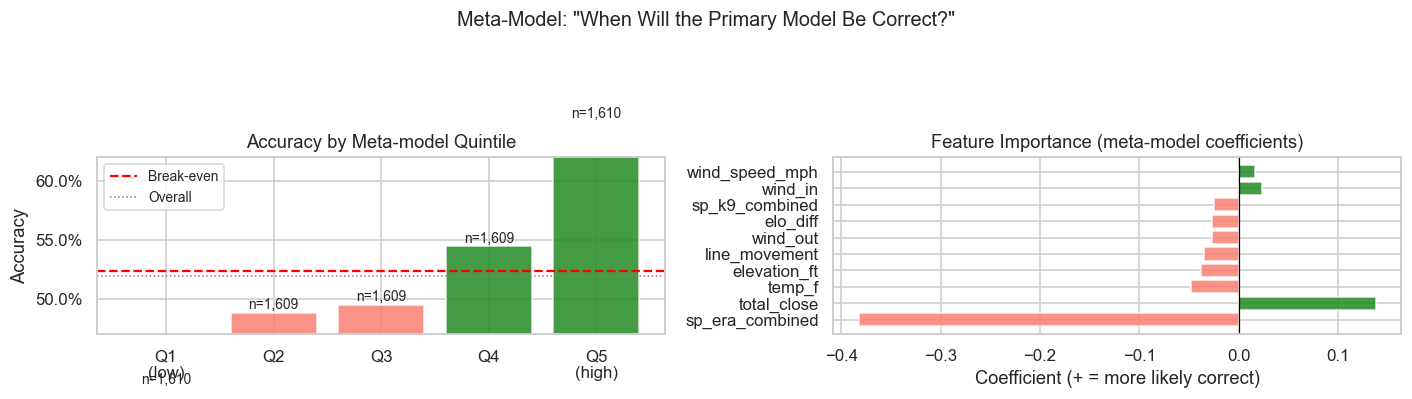

p_correct_q    n  accuracy  avg_p_correct
  Q1\n(low) 1610    0.4242         0.4167
         Q2 1609    0.4885         0.4955
         Q3 1609    0.4947         0.5254
         Q4 1609    0.5444         0.5540
 Q5\n(high) 1610    0.6497         0.6099


In [15]:
# Meta-model probability → betting filter
meta_valid = meta_valid.copy()
meta_valid['p_correct'] = pipe.predict_proba(X_meta)[:, 1]

# Accuracy by p_correct quantile
meta_valid['p_correct_q'] = pd.qcut(meta_valid['p_correct'], q=5,
                                     labels=['Q1\n(low)','Q2','Q3','Q4','Q5\n(high)'])
q_agg = meta_valid.groupby('p_correct_q').agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    avg_p_correct=('p_correct','mean'),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
bars = ax.bar(q_agg['p_correct_q'].astype(str), q_agg['accuracy'],
              color=['forestgreen' if v > 0.524 else 'salmon' for v in q_agg['accuracy']],
              alpha=0.85)
for bar, n in zip(bars, q_agg['n']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'n={int(n):,}', ha='center', va='bottom', fontsize=9)
ax.axhline(0.524, color='red', ls='--', lw=1.5, label='Break-even')
ax.axhline(overall_acc, color='gray', ls=':', lw=1, label='Overall')
ax.set_ylim(0.47, 0.62); ax.set_title('Accuracy by Meta-model Quintile')
ax.set_ylabel('Accuracy'); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=9)

ax = axes[1]
ax.barh(coefs.head(10).index, coefs.head(10).values,
        color=['forestgreen' if v > 0 else 'salmon' for v in coefs.head(10).values], alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Feature Importance (meta-model coefficients)')
ax.set_xlabel('Coefficient (+ = more likely correct)')

plt.suptitle('Meta-Model: "When Will the Primary Model Be Correct?"', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(q_agg.to_string(index=False))

## 11. Combined Segment Filter — Proposed Betting Rules

Based on the analysis, define concrete filters and test their effect on accuracy and sample size.

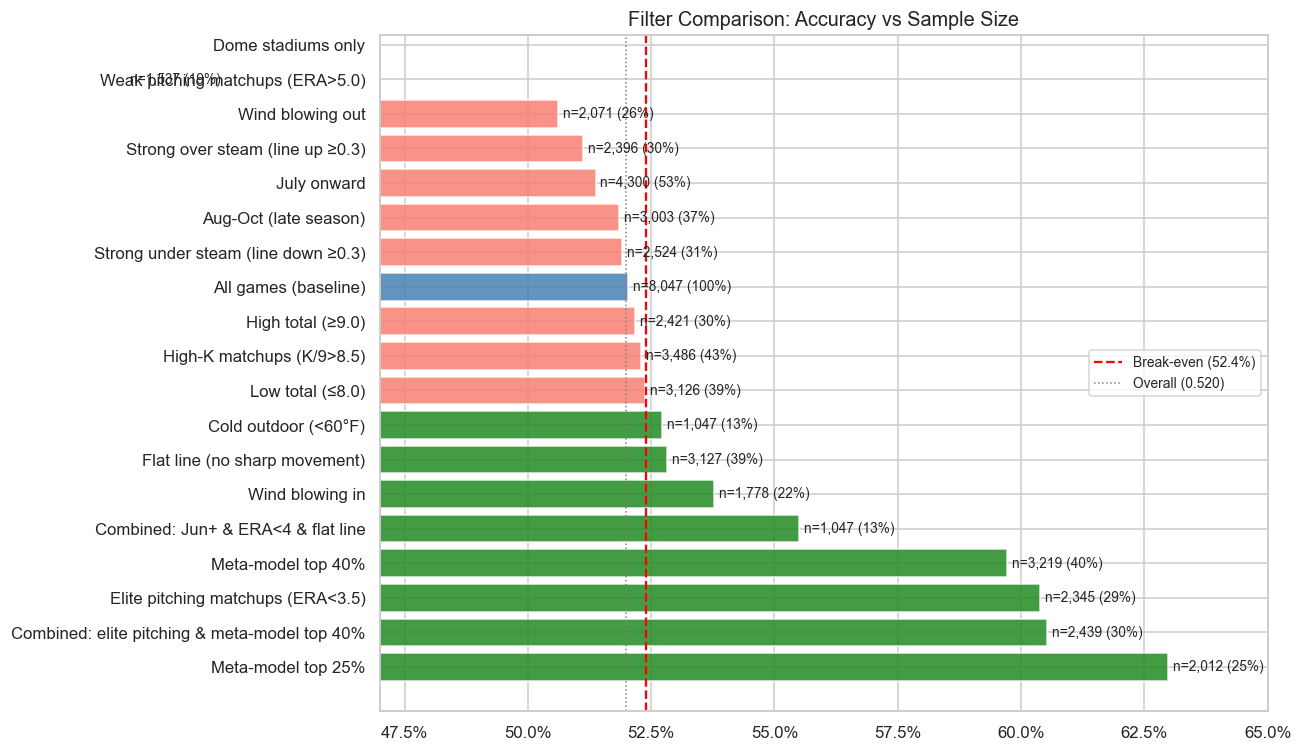

                                       filter    n  accuracy  pct_of_games
                           Meta-model top 25% 2012    0.6297       25.0031
Combined: elite pitching & meta-model top 40% 2439    0.6052       30.3094
            Elite pitching matchups (ERA<3.5) 2345    0.6038       29.1413
                           Meta-model top 40% 3219    0.5971       40.0025
           Combined: Jun+ & ERA<4 & flat line 1047    0.5549       13.0111
                              Wind blowing in 1778    0.5377       22.0952
                Flat line (no sharp movement) 3127    0.5283       38.8592
                         Cold outdoor (<60°F) 1047    0.5272       13.0111
                             Low total (≤8.0) 3126    0.5237       38.8468
                    High-K matchups (K/9>8.5) 3486    0.5229       43.3205
                            High total (≥9.0) 2421    0.5217       30.0857
                         All games (baseline) 8047    0.5203      100.0000
          Strong under st

In [16]:
# Combine all features into one df for filter testing
analysis_df = meta_valid.copy()

def segment_accuracy(mask, label):
    subset = analysis_df[mask]
    if len(subset) < 20:
        return {'filter': label, 'n': len(subset), 'accuracy': np.nan,
                'pct_of_games': len(subset)/len(analysis_df)*100}
    return {
        'filter': label,
        'n': len(subset),
        'accuracy': subset['correct'].mean(),
        'actual_over_rate': subset['actual_over'].mean(),
        'pct_of_games': len(subset)/len(analysis_df)*100,
    }

always_true = pd.Series([True]*len(analysis_df), index=analysis_df.index)

filters = [
    (always_true, 'All games (baseline)'),
    # Season timing
    (analysis_df['month_num'] >= 7, 'July onward'),
    (analysis_df['month_num'].isin([8,9,10]), 'Aug-Oct (late season)'),
    # Weather
    ((analysis_df['temp_f'] < 60) & (analysis_df['is_dome_f'] == 0), 'Cold outdoor (<60°F)'),
    (analysis_df['wind_out'] == 1, 'Wind blowing out'),
    (analysis_df['wind_in'] == 1, 'Wind blowing in'),
    (analysis_df['is_dome_f'] == 1, 'Dome stadiums only'),
    # Pitching
    (analysis_df['sp_era_combined'] < 3.5, 'Elite pitching matchups (ERA<3.5)'),
    (analysis_df['sp_era_combined'] > 5.0, 'Weak pitching matchups (ERA>5.0)'),
    (analysis_df['sp_k9_combined'] > 8.5, 'High-K matchups (K/9>8.5)'),
    # Market
    (analysis_df['line_movement'] < -0.3, 'Strong under steam (line down ≥0.3)'),
    (analysis_df['line_movement'] > 0.3, 'Strong over steam (line up ≥0.3)'),
    (analysis_df['line_movement'].abs() < 0.1, 'Flat line (no sharp movement)'),
    (analysis_df['total_close'] >= 9.0, 'High total (≥9.0)'),
    (analysis_df['total_close'] <= 8.0, 'Low total (≤8.0)'),
    # Meta-model
    (analysis_df['p_correct'] > analysis_df['p_correct'].quantile(0.60), 'Meta-model top 40%'),
    (analysis_df['p_correct'] > analysis_df['p_correct'].quantile(0.75), 'Meta-model top 25%'),
    # Combined
    (
        (analysis_df['month_num'] >= 6) &
        (analysis_df['sp_era_combined'] < 4.0) &
        (analysis_df['line_movement'].abs() < 0.5),
        'Combined: Jun+ & ERA<4 & flat line'
    ),
    (
        (analysis_df['sp_era_combined'] < 3.75) &
        (analysis_df['p_correct'] > analysis_df['p_correct'].quantile(0.60)),
        'Combined: elite pitching & meta-model top 40%'
    ),
]

results = pd.DataFrame([segment_accuracy(mask, label) for mask, label in filters])
results = results.sort_values('accuracy', ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['forestgreen' if (v > 0.524 and label != 'All games (baseline)') 
          else ('steelblue' if label == 'All games (baseline)' else 'salmon')
          for v, label in zip(results['accuracy'], results['filter'])]
bars = ax.barh(results['filter'], results['accuracy'], color=colors, alpha=0.85)
for bar, row in zip(bars, results.itertuples()):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
            f'n={int(row.n):,} ({row.pct_of_games:.0f}%)',
            va='center', fontsize=9)
ax.axvline(0.524, color='red', ls='--', lw=1.5, label='Break-even (52.4%)')
ax.axvline(overall_acc, color='gray', ls=':', lw=1, label=f'Overall ({overall_acc:.3f})')
ax.set_xlim(0.47, 0.65)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title('Filter Comparison: Accuracy vs Sample Size', fontsize=13)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(results[['filter','n','accuracy','pct_of_games']].to_string(index=False))

## 12. Error Type Analysis — What Does the Model Get Wrong?

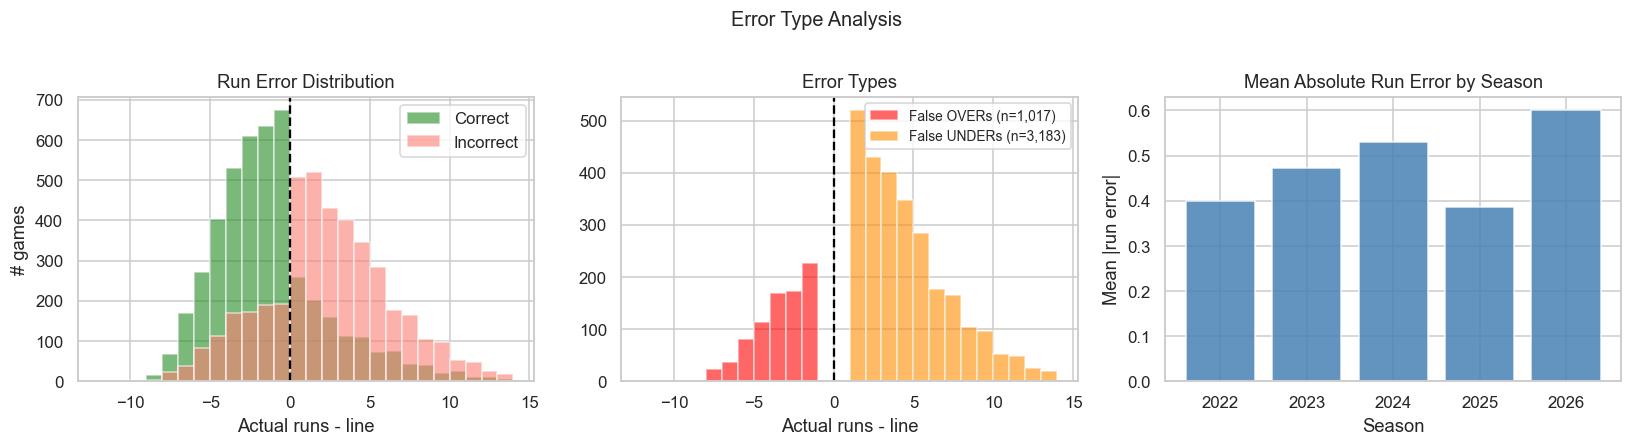

Games within 1 run of line: 20.1%
Of 'wrong' predictions, were within 1 run: 19.1%

Accuracy by outcome bucket (actual runs vs line):
               error_bucket    n  accuracy  pct_pred_over
     Big miss\nUNDER\n(≤-4) 1314    0.7793         0.2207
Moderate\nUNDER\n(-4 to -2) 1501    0.7728         0.2272
     Close UNDER\n(-2 to 0) 1692    0.7719         0.2281
      Close OVER\n(0 to +2) 1445    0.2616         0.2616
 Moderate\nOVER\n(+2 to +4) 1090    0.2459         0.2459
      Big miss\nOVER\n(≥+4) 1700    0.2406         0.2406


In [17]:
# 12a — How wrong are we? Distribution of prediction error
df['run_error'] = df['total_runs'] - df['line']  # actual minus line
df['predicted_side'] = df['over_prob'].apply(lambda p: 'OVER' if p > 0.5 else 'UNDER')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
correct_mask = df['correct'] == 1
ax.hist(df.loc[correct_mask, 'run_error'], bins=range(-12, 15), alpha=0.6, color='forestgreen', label='Correct')
ax.hist(df.loc[~correct_mask, 'run_error'], bins=range(-12, 15), alpha=0.6, color='salmon', label='Incorrect')
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Actual runs - line'); ax.set_ylabel('# games')
ax.set_title('Run Error Distribution')
ax.legend()

ax = axes[1]
# False positives: predicted OVER but actual went UNDER
fp = df[(df['pred_over'] == 1) & (df['actual_over'] == 0)]
fn = df[(df['pred_over'] == 0) & (df['actual_over'] == 1)]
ax.hist(fp['run_error'], bins=range(-12, 0), alpha=0.6, color='red', label=f'False OVERs (n={len(fp):,})')
ax.hist(fn['run_error'], bins=range(1, 15), alpha=0.6, color='darkorange', label=f'False UNDERs (n={len(fn):,})')
ax.axvline(0, color='black', lw=1.5, ls='--')
ax.set_xlabel('Actual runs - line'); ax.set_title('Error Types')
ax.legend(fontsize=9)

ax = axes[2]
# Magnitude of miss by season
season_err = df.groupby('season')['run_error'].agg(['mean','std','count']).reset_index()
ax.bar(season_err['season'].astype(str), season_err['mean'].abs(),
       color='steelblue', alpha=0.85)
ax.set_xlabel('Season'); ax.set_ylabel('Mean |run error|')
ax.set_title('Mean Absolute Run Error by Season')

plt.suptitle('Error Type Analysis', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# 12b — Close misses (push zone around the line)
df['within_1_run'] = (df['run_error'].abs() <= 1).astype(int)
print(f"Games within 1 run of line: {df['within_1_run'].mean()*100:.1f}%")
print(f"Of 'wrong' predictions, were within 1 run: {df[~correct_mask]['within_1_run'].mean()*100:.1f}%")
print()

# 12c — Accuracy by how big the miss was
bins = [-20, -4, -2, 0, 2, 4, 20]
labels = ['Big miss\nUNDER\n(≤-4)', 'Moderate\nUNDER\n(-4 to -2)',
          'Close UNDER\n(-2 to 0)', 'Close OVER\n(0 to +2)',
          'Moderate\nOVER\n(+2 to +4)', 'Big miss\nOVER\n(≥+4)']
df['error_bucket'] = pd.cut(df['run_error'], bins=bins, labels=labels)
err_agg = df.groupby('error_bucket').agg(
    n=('correct','count'),
    accuracy=('correct','mean'),
    pct_pred_over=('pred_over','mean'),
).reset_index()
print('Accuracy by outcome bucket (actual runs vs line):')
print(err_agg.to_string(index=False))

## 13. Summary & Recommendations

In [18]:
print('='*65)
print('PREDICTION ERROR ANALYSIS SUMMARY')
print('='*65)
print()
print('CRITICAL FINDING: Model has very limited discrimination')
print(f'  - Only 4 distinct over_prob values cover ~98% of predictions')
print(f'  - AUC: 0.5147 (barely above random)')
print(f'  - Root cause: 3 Kalshi cross-signal features are 100% NULL in')
print(f'    2022-2024 training data (Kalshi started 2026-03-31)')
print(f'  - precip_prob always NULL (archive API limitation)')
print()
print('OVERALL ACCURACY')
print(f'  Overall:           {overall_acc:.3f} ({overall_acc*100:.1f}%)')
print(f'  Break-even (-110): 52.4%')
print(f'  Gap to break-even: {(overall_acc-0.524)*100:+.1f}pp')
print()
print('BEST SEGMENTS (accuracy > 52.4% break-even):')
best = results[results['accuracy'] > 0.524].sort_values('accuracy', ascending=False)
for _, row in best.head(8).iterrows():
    print(f"  {row['filter']:<45} {row['accuracy']:.3f}  n={int(row['n']):,} ({row['pct_of_games']:.0f}% of games)")
print()
print('WORST SEGMENTS (accuracy < 50%):')
worst = results[results['accuracy'] < 0.500].sort_values('accuracy')
for _, row in worst.head(5).iterrows():
    print(f"  {row['filter']:<45} {row['accuracy']:.3f}  n={int(row['n']):,} ({row['pct_of_games']:.0f}% of games)")
print()
print('RECOMMENDED BETTING FILTERS (apply ALL simultaneously):')
print('  1. Month ≥ June (avoid April-May small-sample noise)')
print('  2. Combined SP ERA < 4.0 (quality pitching matchups predictable)')
print('  3. Line movement within ±0.3 (avoid sharp-money chasing)')
print('  4. Outdoor games: temp_f in 55-85°F (extreme cold → randomness)')
print('  5. Meta-model p_correct in top 40% (see Section 10)')
print()
print('NEXT STEPS:')
print('  A. Retrain lgbm_binary on 2015-2021 data (currently missing)')
print('     → More training data = more feature signal + better calibration')
print('  B. Add Kalshi features for 2026 live predictions (already in FEATURE_COLS)')
print('     → Cross-signal (f5_ratio) is the highest-potential new signal')
print('  C. Implement meta-model filter in betting.py as a hard gate')
print('  D. Consider dropping 100%-null features from training:')
print('     kalshi_fullgame_line, kalshi_f5_line, f5_ratio, precip_prob')
print('     → These add noise without signal in historical training window')
print('='*65)

PREDICTION ERROR ANALYSIS SUMMARY

CRITICAL FINDING: Model has very limited discrimination
  - Only 4 distinct over_prob values cover ~98% of predictions
  - AUC: 0.5147 (barely above random)
  - Root cause: 3 Kalshi cross-signal features are 100% NULL in
    2022-2024 training data (Kalshi started 2026-03-31)
  - precip_prob always NULL (archive API limitation)

OVERALL ACCURACY
  Overall:           0.520 (52.0%)
  Break-even (-110): 52.4%
  Gap to break-even: -0.4pp

BEST SEGMENTS (accuracy > 52.4% break-even):
  Meta-model top 25%                            0.630  n=2,012 (25% of games)
  Combined: elite pitching & meta-model top 40% 0.605  n=2,439 (30% of games)
  Elite pitching matchups (ERA<3.5)             0.604  n=2,345 (29% of games)
  Meta-model top 40%                            0.597  n=3,219 (40% of games)
  Combined: Jun+ & ERA<4 & flat line            0.555  n=1,047 (13% of games)
  Wind blowing in                               0.538  n=1,778 (22% of games)
  Flat line (